# ClimX Playground

This notebook provides a end-to-end pipeline for model development. 

In [1]:
#Autoreload .py files
%load_ext autoreload
%autoreload 2

#https://github.com/chmp/ipytest/issues/80
import sys
sys.breakpointhook = sys.__breakpointhook__

Uset the `setup_logger` function to set the logging level to `INFO` or `DEBUG` at any time during the notebook.

In [2]:
from src.utils.logging_utils import setup_logger, logging
setup_logger(logging.INFO)

2026-02-22 17:09:03,586 - root - INFO - Logger configured with level: INFO


# Data loading and preprocessing

Data can be found at hugging face link 

In [ ]:
# Import necessary libraries
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np


# Set plot style
plt.style.use('ggplot')
sns.set_context("notebook", font_scale=1.2)

# Configure plots to be larger
plt.rcParams['figure.figsize'] = [12, 8]

# Display all rows and columns of xarray datasets
xr.set_options(display_width=200, display_max_rows=200)

# Define data version
DATA_VERSION = 'lite' # Options: 'lite', 'full'
stationarization_mode = 'monthly'

# Define variables configuration
TARGET_VARIABLES = ['huss', 'pr', 'psl', 'sfcWind', 'tas', 'tasmax', 'tasmin']
GREENHOUSE_GAS_AGENTS = ['CO2_LBC', 'N2O_LBC', 'CH4_LBC', 'CFC11eq_LBC', 'CF2CL2_LBC']
AEROSOL_AGENTS = ['BC_AX', 'BC_N', 'SO2', 'SO4_PR', 'OM_NI']
ALL_FORCING_VARS = GREENHOUSE_GAS_AGENTS + AEROSOL_AGENTS

# Path to the data
output_path = Path('/data/users/climate_challenge/final/')
data_path = Path('data/')
forcing_data_path = Path('/data/users/climate_challenge/data/forcing/inputs/')
nc_data_path = data_path / 'ncfiles'

In [4]:
# --- Ensure data exists locally; otherwise download from Hugging Face ---
import os
from pathlib import Path
from src.utils.hugging_face_utils import get_dataset_from_hf

# Download into data_path if not already present
get_dataset_from_hf(data_path, variant=DATA_VERSION)

/home/nathan/miniconda3/envs/clima_emu_new/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data already present: data


/home/nathan/miniconda3/envs/clima_emu_new/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:186: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(
/home/nathan/miniconda3/envs/clima_emu_new/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Data already present: data
2026-02-22 17:09:05,556 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/datasets/isp-uv-es/ClimX/revision/main "HTTP/1.1 200 OK"


Fetching 7 files: 100%|██████████| 7/7 [00:00<00:00, 1661.67it/s]

Download complete.


In [5]:
# --- Load the dataset ---
from src.utils.hugging_face_utils import open_climx_virtual_datasets
dataset = open_climx_virtual_datasets(data_path, DATA_VERSION)

/home/mariag/.conda/envs/clima_emu_new/lib/python3.11/site-packages/dask/array/reductions.py:654: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


In [ ]:
# --- Preprocess the data (id needed) ---
from src.data_preprocessing.preprocessing import preprocess_train

preprocessing_path = Path(f"preprocessing_data_{DATA_VERSION}/") 
precomputed = True
save_preprocessed = False

# Load and preprocess the training data
if not precomputed:
    X_train, y_train, metadata = preprocess_train(
        dataset, 
        preprocessing_path=preprocessing_path,
        version='lite',
        scaling_params_path='preprocessing_data_lite/scaling_params_lite.json'
    )
    if save_preprocessed:
        X_train = X_train.chunk({'time': 30, 'lat': -1, 'lon': -1})
        X_train.to_netcdf(f'preprocessing_data_{DATA_VERSION}/X_train.nc')
        y_train = y_train.chunk({'time': 30, 'lat': -1, 'lon': -1})
        y_train.to_netcdf(f'preprocessing_data_{DATA_VERSION}/y_train.nc')
else:
    X_train = xr.open_dataset(preprocessing_path / 'X_train.nc')
    y_train = xr.open_dataset(preprocessing_path / 'y_train.nc')

# Training 

In [7]:
# Define model to train
model_type = 'nn' # implemented options in models/: climatology, nn, gnn 

# Instantiate the appropriate model
if model_type == 'climatology':
    from src.models.climatology_model import ClimatologyBaseline
    emulator = ClimatologyBaseline()
    model_path = Path(f'models_{DATA_VERSION}') / f'{model_type}.nc'
    trainer_params = {} # No training parameters needed for climatology model
    
elif model_type == 'nn':
    from src.models.nn_model import NNBaseline
    import torch
    torch.manual_seed(42)  # For reproducibility
    # NN model requires parameters at initialization
    model_params = {
        'n_lat': 192, # This should match the subsampled data
        'n_lon': 288, # This should match the subsampled data
        'n_forcing_vars': 22,
        'n_target_vars': 7,
        'learning_rate': 1e-3,
        'separate_output_heads': True, # Whether to have separate output heads for each variable
    }
    model_path = Path(f'models_{DATA_VERSION}') / f'{model_type}'
    trainer_params = {'max_epochs': 5, 'model_path': model_path} 

    emulator = NNBaseline(model_params)

elif model_type == 'gnn':
    pass
else:
    raise ValueError(f"Unknown model type: {model_type}")

print(f"Using '{model_type}' model. Model will be saved to: {model_path}")

2026-02-22 17:09:10,669 - pint.util - WARNING - Redefining 'percent' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
2026-02-22 17:09:10,670 - pint.util - WARNING - Redefining '%' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
2026-02-22 17:09:10,670 - pint.util - WARNING - Redefining 'year' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
2026-02-22 17:09:10,671 - pint.util - WARNING - Redefining 'yr' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
2026-02-22 17:09:10,671 - pint.util - WARNING - Redefining 'C' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
2026-02-22 17:09:10,672 - pint.util - WARNING - Redefining 'd' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
2026-02-22 17:09:10,673 - pint.util - WARNING - Redefining 'h' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
2026-02-22 17:09:10,673 - pint.util - WARNING - Redefining 'degrees_north' (<class 'pint.delegates.txt_defparser.pl

2026-02-22 17:11:52,745 - src.models.nn_model - INFO - {'max_epochs': 5, 'model_path': PosixPath('models_lite/nn')}
2026-02-22 17:11:52,749 - src.models.nn_model - INFO - NNBaseline fitting ...
2026-02-22 17:11:52,771 - pytorch_lightning.utilities.rank_zero - INFO - GPU available: True (cuda), used: True
2026-02-22 17:11:52,771 - pytorch_lightning.utilities.rank_zero - INFO - TPU available: False, using: 0 TPU cores
2026-02-22 17:11:52,773 - pytorch_lightning.accelerators.cuda - INFO - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
2026-02-22 17:11:52,776 - pytorch_lightning.callbacks.model_summary - INFO - 
  | Name      | Type       | Params | Mode 
-------------------------------------------------
0 | embedding | Embedding  | 442 K  | train
1 | fc1       | Linear     | 4.0 K  | train
2 | fc2       | Linear     | 16.5 K | train
3 | heads     | ModuleList | 903    | train
4 | relu      | ReLU       | 0      | train
-------------------------------------------------
463 K     Trainable param

/home/mariag/.conda/envs/clima_emu_new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 8, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/home/mariag/.conda/envs/clima_emu_new/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/mariag/.conda/envs/clima_emu_new/lib/python3.1 ...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/nathan/miniconda3/envs/clima_emu_new/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/nathan/miniconda3/envs/clima_emu_new/lib/python3.11/site-packages/pytorch_lightning/utilities/data.py:123: Your `IterableDataset` has `__len__` defined. In combination with multi-process data loading (when num_workers > 1), `__len__` could be inaccurate if each worker is not configured independently to avoid having duplicate data.


Epoch 4: 100%|██████████| 2409/2409 [00:34<00:00, 70.08it/s, train_loss_step=0.643, val_loss=0.779, train_loss_epoch=0.742]2026-02-22 17:14:57,973 - pytorch_lightning.callbacks.early_stopping - INFO - Metric val_loss improved by 0.009 >= min_delta = 0.0001. New best score: 0.779
2026-02-22 17:14:58,171 - pytorch_lightning.utilities.rank_zero - INFO - `Trainer.fit` stopped: `max_epochs=5` reached.
Epoch 4: 100%|██████████| 2409/2409 [00:34<00:00, 69.68it/s, train_loss_step=0.643, val_loss=0.779, train_loss_epoch=0.742]
2026-02-22 17:14:58,660 - src.models.nn_model - INFO - NNBaseline.fit completed.
2026-02-22 17:14:58,660 - src.models.nn_model - INFO - Final training loss: 0.7416
2026-02-22 17:14:58,736 - src.models.nn_model - INFO - NNBaseline model saved to models_lite/nn
'nn' model trained and saved to models_lite/nn


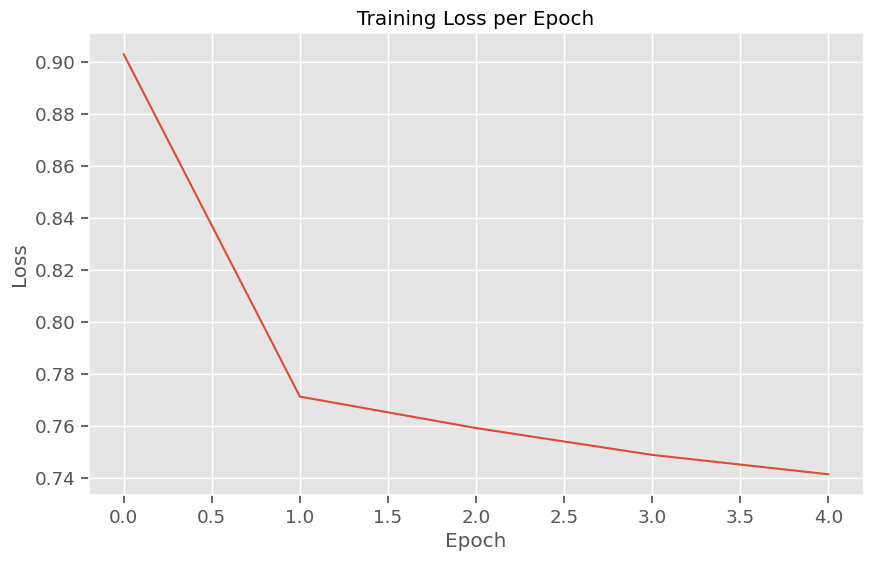

In [8]:
# Fit the model
FIT_MODEL = True

# Fit and save the model
if FIT_MODEL:
    emulator.fit(X_train, y_train, trainer_params=trainer_params)
    emulator.save(model_path)
    print(f"'{model_type}' model trained and saved to {model_path}")
else:
    # Load the model
    emulator.load(model_path / 'last.ckpt')
    print(f"'{model_type}' model loaded from {model_path}")

# Plot the loss
if hasattr(emulator, 'plot_loss'):
    emulator.plot_loss()

# Evaluation

In [23]:
# --- Evaluate the selected model ---
from src.data_preprocessing.preprocessing import preprocess_test

precomputed = False
save_preprocessed = False
precomputed = True

# Load and preprocess the test data
if not precomputed:
    X_test, metadata_test = preprocess_test(
        dataset, 
        preprocessing_path=preprocessing_path,
        version='lite',
        scaling_params_path=preprocessing_path / f'scaling_params_{DATA_VERSION}.json',
    )
    if save_preprocessed:
        X_test = X_test.astype(np.float32).chunk({'time': 30, 'lat': -1, 'lon': -1})
        print("Saving X_test...")
        encoding = {var: {'zlib': False, '_FillValue': None} for var in X_test.data_vars}

        from dask.diagnostics import ProgressBar

        X_test.to_netcdf(preprocessing_path / "X_test.nc", encoding=encoding, compute=False)
       
else:
    import json 

    print("Loading preprocessed test data ...")
    X_test = xr.open_dataset(preprocessing_path / 'X_test.nc')
    metadata_test = {
        'climatology_path': str(preprocessing_path / f'climatology_{DATA_VERSION}.nc'),
        'scaling_params_path': str(preprocessing_path / f'scaling_params_{DATA_VERSION}.json'),
        'scaling_params': json.load(open(preprocessing_path / f'scaling_params_{DATA_VERSION}.json')),
        'stationarization_mode': stationarization_mode,
    }


# Define paths for evaluation results
results_path = Path(f'./results_{DATA_VERSION}/{model_type}_evaluation.json')
predictions_path = Path(f'./results_{DATA_VERSION}/{model_type}_predictions.zarr')

# Evaluate the model
y_pred, indices_pred = emulator.evaluate(
    X_test, 
    metadata_test, 
    results_path, 
    predictions_path,
    dataset.hist, 
    TARGET_VARIABLES=TARGET_VARIABLES,
    LOAD_PREDICTIONS=True,
    compute_indices=True,
 )

print(f"Evaluation for '{model_type}' model complete.")

Loading preprocessed test data ...
2026-02-22 17:16:48,869 - src.models.emulator - INFO - Making predictions...
2026-02-22 17:16:48,870 - src.models.nn_model - INFO - Making NNBaseline predictions (streaming): time_dim=time, time=31389, lat=12, lon=18, features=12, targets=7
2026-02-22 17:16:48,870 - src.models.nn_model - WARNING - out_path was not provided; predictions will be assembled in-memory and may be very large (time=31389, lat=12, lon=18, targets=7).


Predicting: 100%|██████████| 1047/1047 [00:09<00:00, 107.52chunk/s]


2026-02-22 17:16:59,097 - src.models.emulator - INFO - Reversing preprocessing for predictions...
2026-02-22 17:16:59,109 - src.data_preprocessing.preprocessing_utils - INFO - Unscaled tas using standardize method
2026-02-22 17:16:59,118 - src.data_preprocessing.preprocessing_utils - INFO - Unscaled tasmax using standardize method
2026-02-22 17:16:59,126 - src.data_preprocessing.preprocessing_utils - INFO - Unscaled tasmin using standardize method
2026-02-22 17:16:59,134 - src.data_preprocessing.preprocessing_utils - INFO - Unscaled pr using standardize method
2026-02-22 17:16:59,143 - src.data_preprocessing.preprocessing_utils - INFO - Unscaled huss using standardize method
2026-02-22 17:16:59,151 - src.data_preprocessing.preprocessing_utils - INFO - Unscaled psl using standardize method
2026-02-22 17:16:59,159 - src.data_preprocessing.preprocessing_utils - INFO - Unscaled sfcWind using standardize method
2026-02-22 17:16:59,176 - src.data_preprocessing.preprocessing_utils - INFO - Va

Indices: R10mm: 100%|██████████| 15/15 [00:30<00:00,  2.06s/it]

Evaluation for 'nn' model complete.


/home/nathan/miniconda3/envs/clima_emu_new/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/nathan/miniconda3/envs/clima_emu_new/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/nathan/miniconda3/envs/clima_emu_new/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/nathan/miniconda3/envs/clima_emu_new/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


In [12]:
# --- Prepare Kaggle submission ---
import src.utils.kaggle_submission as ks
from src.utils.indices_utils import format_indices
precomputed_indices = False

if not precomputed_indices:
    # Format the indices and save as .nc (optional)
    indices_pred = format_indices(indices_pred, model_type, DATA_VERSION, save_indices=True)
    indices_pred = xr.Dataset(indices_pred)

    if DATA_VERSION == 'lite':
        # Upscale indices to original resolution (x16 in each spatial dimension).
        # IMPORTANT: your target grid (LAT/LON) extends beyond the coarse grid bounds,
        # and xarray fills out-of-bounds with NaN by default even with method='nearest'.
        # Using fill_value='extrapolate' prevents those edge NaNs by repeating boundary values.
        from src.utils.original_data_values import LAT, LON
        lat = np.asarray(LAT, dtype=float)
        lon = np.asarray(LON, dtype=float)

        # Make sure source coords are sorted/monotonic for interpolation
        indices_pred = indices_pred.sortby('lat').sortby('lon')
        indices_pred = indices_pred.interp(
            lat=lat,
            lon=lon,
            method='nearest',
            kwargs={'fill_value': 'extrapolate'},
        )

else:
    # Load the indices 
    indices_pred = xr.open_dataset(f"results_{DATA_VERSION}/{model_type}_indices.nc")

# Save the indices in the required format for Kaggle submission
submission_path = Path(f'submission_{DATA_VERSION}/submission_{model_type}.parquet')
ks.write_kaggle_submission_parquet(indices_pred, submission_path)

PosixPath('submission_lite/submission_nn.parquet')

# Visualization of results

In [13]:
# Visualize the results
save_dir = Path(f"results_{DATA_VERSION}/{model_type}_visuals")
emulator.visualize(
    y_pred,
    indices_pred, 
    save_dir,
    variables_to_plot={'y': ['tas', 'tasmax', 'tasmin', 'pr', 'huss', 'psl', 'sfcWind'], 
                       'indices': ['FD', 'SU', 'ID', 'TR', 'GSL', 'CDD', 'CWD', 'SDII', 'R10mm', 'R95p', 'Rx5day', 'TXx', 'TNn', 'WSDI', 'CSDI']},
    time_index=50,
    lat=40.0,
    lon=-95.0
)
print(f"Visualizations saved to {save_dir}")

2026-02-22 17:18:28,049 - src.models.emulator - INFO - Visualizing results...


2026-02-22 17:18:28,599 - src.visualization.utils - INFO - Saved plot to results_lite/nn_visuals/result_map_tas_2015-02-20.png
2026-02-22 17:18:28,880 - src.visualization.utils - INFO - Saved plot to results_lite/nn_visuals/result_timeseries_tas_40.0_-95.0.png
2026-02-22 17:18:29,395 - src.visualization.utils - INFO - Saved plot to results_lite/nn_visuals/result_map_tasmax_2015-02-20.png
2026-02-22 17:18:29,635 - src.visualization.utils - INFO - Saved plot to results_lite/nn_visuals/result_timeseries_tasmax_40.0_-95.0.png
2026-02-22 17:18:30,241 - src.visualization.utils - INFO - Saved plot to results_lite/nn_visuals/result_map_tasmin_2015-02-20.png
2026-02-22 17:18:30,854 - src.visualization.utils - INFO - Saved plot to results_lite/nn_visuals/result_timeseries_tasmin_40.0_-95.0.png
2026-02-22 17:18:31,406 - src.visualization.utils - INFO - Saved plot to results_lite/nn_visuals/result_map_pr_2015-02-20.png
2026-02-22 17:18:31,648 - src.visualization.utils - INFO - Saved plot to result